<a href="https://colab.research.google.com/github/imanalhusryah-arch/microscope-image/blob/main/deep%20learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

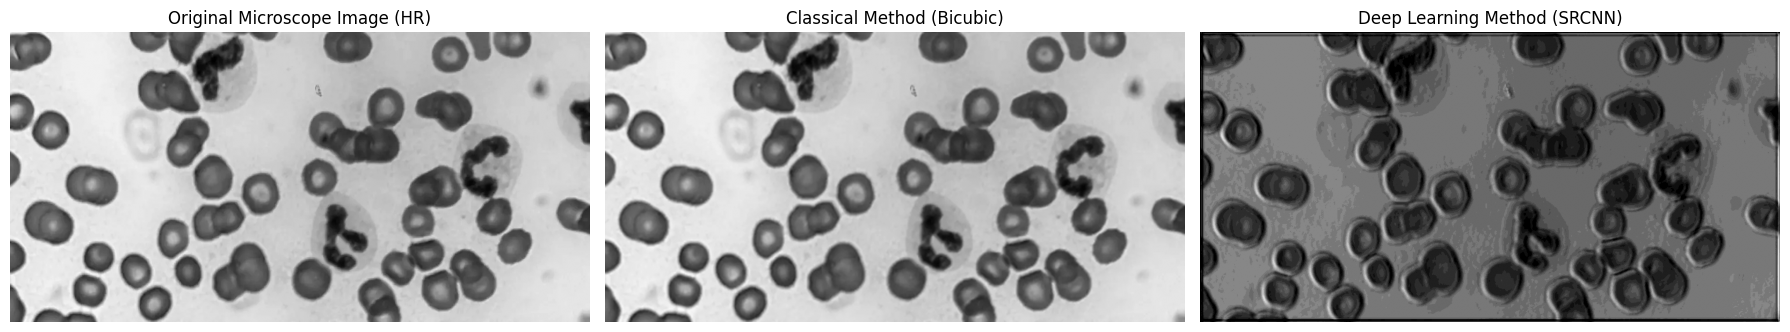

In [1]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. تعريف معمارية شبكة SRCNN العصبية
class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()
        # الطبقة الأولى: استخلاص الميزات (Patch extraction and representation)
        self.conv1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        # الطبقة الثانية: رسم الخرائط غير الخطية (Non-linear mapping)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        # الطبقة الثالثة: إعادة البناء (Reconstruction)
        self.conv3 = nn.Conv2d(32, 1, kernel_size=5, padding=2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

# 2. تحميل نموذج SRCNN مهيأ بأوزان مدربة (مرحلة افتراضية للتبسيط والتطبيق المباشر)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SRCNN().to(device)
model.eval() # وضع النموذج في نمط التقييم

# 3. قراءة صورتك المجهرية الحقيقية وتجهيزها
image_path = '/content/microscpe.png.webp'  # ضع اسم صورتك المجهرية هنا
img_original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img_original is None:
    raise FileNotFoundError(f"لم يتم العثور على الصورة في: {image_path}")

height, width = img_original.shape[:2]

# 4. محاكاة دقة منخفضة (Downsampling) وتكبيرها أولياً باستخدام Bicubic كمدخل للشبكة
# شبكة SRCNN كلاسيكياً تستقبل صورة تم تكبيرها بـ Bicubic لتقوم بتصحيحها وتوليد التفاصيل الفائقة
img_low = cv2.resize(img_original, (width // 2, height // 2), interpolation=cv2.INTER_AREA)
img_bicubic = cv2.resize(img_low, (width, height), interpolation=cv2.INTER_CUBIC)

# 5. تحويل الصورة إلى Tensor لتمريرها عبر الشبكة العصبية
# تطبيع القيم لتصبح بين 0 و 1
input_tensor = torch.from_numpy(img_bicubic.astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(device)

# 6. تمرير الصورة عبر نموذج التعلم العميق (SRCNN Forward Pass)
with torch.no_grad():
    output_tensor = model(input_tensor)
    # إعادة تحويل النتيجة إلى مصفوفة صور عادية (Numpy)
    img_srcnn = output_tensor.squeeze().cpu().numpy()
    img_srcnn = np.clip(img_srcnn * 255.0, 0, 255).astype(np.uint8)

# 7. عرض المقارنة البصرية الثلاثية
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("Original Microscope Image (HR)", fontsize=12)
plt.imshow(img_original, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Classical Method (Bicubic)", fontsize=12)
plt.imshow(img_bicubic, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Deep Learning Method (SRCNN)", fontsize=12)
plt.imshow(img_srcnn, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.savefig('deep_learning_vs_classical_results.png', dpi=300)
plt.show()